In [1]:
!pip install nltk textblob
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\sneha\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize the VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Simulated data from your specified sources (Amazon, Social Media, News)
raw_data = [
    {
        "Source": "Amazon Review", 
        "Text": "The product broke within two days of light use. Absolute garbage, do not buy!"
    },
    {
        "Source": "Social Media (Twitter)", 
        "Text": "OMG! Just tried the new feature on the app and it is incredibly smooth! game changer "
    },
    {
        "Source": "News Headline", 
        "Text": "The central bank announced steady interest rates amid a flat economic outlook this quarter."
    },
    {
        "Source": "Amazon Review", 
        "Text": "It works fine, nothing special. It does what it says on the box, I guess."
    }
]

# Create DataFrame
df_sentiment = pd.DataFrame(raw_data)

# Analysis Function
def analyze_sentiment(text):
    # Get the raw polarity scores dictionary: {'neg', 'neu', 'pos', 'compound'}
    scores = sia.polarity_scores(text)
    compound_score = scores['compound']
    
    # Classify sentiment based on the standard compound threshold
    if compound_score >= 0.05:
        classification = "Positive"
    elif compound_score <= -0.05:
        classification = "Negative"
    else:
        classification = "Neutral"
        
    return pd.Series([compound_score, classification])

# Apply analysis to create two new feature columns
df_sentiment[['Compound_Score', 'Sentiment']] = df_sentiment['Text'].apply(analyze_sentiment)

print(" SENTIMENT CLASSIFICATION MATRIX:")
print(df_sentiment[["Source", "Sentiment", "Compound_Score"]])

 SENTIMENT CLASSIFICATION MATRIX:
                   Source Sentiment  Compound_Score
0           Amazon Review  Negative         -0.4753
1  Social Media (Twitter)   Neutral          0.0000
2           News Headline  Positive          0.4588
3           Amazon Review  Negative         -0.1174


In [5]:
def detect_specific_emotion(text):
    text_lower = text.lower()
    # Simple semantic lexicon mapping
    emotions = {
        "Anger/Frustration": ["broke", "garbage", "hate", "worst", "terrible"],
        "Joy/Excitement": ["omg", "smooth", "game changer", "love", "amazing"],
        "Uncertainty/Caution": ["flat", "steady", "guess", "neutral", "mid"]
    }
    
    for emotion, keywords in emotions.items():
        if any(keyword in text_lower for keyword in keywords):
            return emotion
    return "Undetermined"

df_sentiment['Predominant_Emotion'] = df_sentiment['Text'].apply(detect_specific_emotion)
print("\n DEEP EMOTION DETECTION INSIGHTS:")
print(df_sentiment[["Source", "Sentiment", "Predominant_Emotion"]])


 DEEP EMOTION DETECTION INSIGHTS:
                   Source Sentiment  Predominant_Emotion
0           Amazon Review  Negative    Anger/Frustration
1  Social Media (Twitter)   Neutral       Joy/Excitement
2           News Headline  Positive  Uncertainty/Caution
3           Amazon Review  Negative  Uncertainty/Caution


In [7]:
def generate_business_insight(row):
    if row['Sentiment'] == 'Negative' and row['Source'] == 'Amazon Review':
        return " PRODUCT ALERT: Quality defect flagged in reviews. Immediate engineering review required."
    elif row['Sentiment'] == 'Positive' and row['Source'] == 'Social Media (Twitter)':
        return " MARKETING OPPORTUNITY: High user engagement. Boost this post for viral marketing campaign."
    elif row['Sentiment'] == 'Neutral' and row['Source'] == 'News Headline':
        return " MARKET WATCH: Stable public interest. No immediate brand shift detected."
    return " MONITORING: Keep tracking user sentiment patterns."

df_sentiment['Strategic_Action'] = df_sentiment.apply(generate_business_insight, axis=1)

print("\n STRATEGIC ROADMAP FOR MANAGEMENT:")
for idx, row in df_sentiment.iterrows():
    print(f"\n[{row['Source']} Sentiment Summary]: {row['Sentiment']} ({row['Predominant_Emotion']})")
    print(f" Actionable Insight: {row['Strategic_Action']}")


 STRATEGIC ROADMAP FOR MANAGEMENT:

[Amazon Review Sentiment Summary]: Negative (Anger/Frustration)
 Actionable Insight:  PRODUCT ALERT: Quality defect flagged in reviews. Immediate engineering review required.

[Social Media (Twitter) Sentiment Summary]: Neutral (Joy/Excitement)
 Actionable Insight:  MONITORING: Keep tracking user sentiment patterns.

[News Headline Sentiment Summary]: Positive (Uncertainty/Caution)
 Actionable Insight:  MONITORING: Keep tracking user sentiment patterns.

[Amazon Review Sentiment Summary]: Negative (Uncertainty/Caution)
 Actionable Insight:  PRODUCT ALERT: Quality defect flagged in reviews. Immediate engineering review required.


In [9]:
# Creating a raw text data feed simulating different online channels
with open("raw_feed.txt", "w", encoding="utf-8") as file:
    file.write("AMAZON_REVIEW: The item arrived completely shattered inside the box. Terrible packaging, demanding a full refund!\n")
    file.write("TWITTER_FEED: Can we talk about how amazing the customer service team was today? Resolved my checkout bug in under 5 minutes! 🙌\n")
    file.write("NEWS_HEADLINE: Market indicators point to a massive surge in tech stock valuations as retail investments hit historic highs.\n")
    file.write("AMAZON_REVIEW: The product is okay. It operates exactly as expected, though the shipping timeline was slightly delayed.\n")
    file.write("TWITTER_FEED: Honestly so frustrated with the lag on the new update. The app keeps freezing every time I try to open messages. Fix this.\n")
    file.write("NEWS_HEADLINE: Regulatory bodies launch preliminary investigation into data compliance standards across major online platforms.\n")

print("'raw_feed.txt' successfully created with 6 multi-source text strings!")

'raw_feed.txt' successfully created with 6 multi-source text strings!


In [11]:
import pandas as pd
import re
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize our core NLTK analyzer
sia = SentimentIntensityAnalyzer()

processed_records = []

print(" Opening 'raw_feed.txt' for text ingestion...")

with open("raw_feed.txt", "r", encoding="utf-8") as file:
    for line_number, line in enumerate(file, 1):
        line = line.strip()
        if not line:
            continue # Skip accidental blank lines safely
            
        try:
            # Separate the source prefix from the actual text body
            if ":" in line:
                source, text_body = line.split(":", 1)
                source = source.strip()
                text_body = text_body.strip()
            else:
                source = "UNKNOWN_SOURCE"
                text_body = line
            
            # --- NLP Feature Extraction ---
            # VADER returns a dict: {'neg', 'neu', 'pos', 'compound'}
            scores = sia.polarity_scores(text_body)
            compound = scores['compound']
            
            # Categorize sentiment based on industry standard bounds (-0.05 to 0.05)
            if compound >= 0.05:
                sentiment = "Positive"
            elif compound <= -0.05:
                sentiment = "Negative"
            else:
                sentiment = "Neutral"
                
            # --- Rule-Based Emotion Mapping ---
            text_lower = text_body.lower()
            emotion = "Neutral/Objective" # Default fallback
            
            # Simple lexicon maps to catch thematic phrasing
            if any(w in text_lower for w in ["shattered", "terrible", "frustrated", "lag", "freezing", "fix"]):
                emotion = "Anger/Frustration"
            elif any(w in text_lower for w in ["amazing", "resolved", "surge", "highs"]):
                emotion = "Joy/Excitement"
            elif any(w in text_lower for w in ["investigation", "compliance", "regulatory"]):
                emotion = "Caution/Risk"

            # Append the structured record to our tracking collection
            processed_records.append({
                "Line": line_number,
                "Source": source,
                "Text": text_body,
                "Compound_Score": compound,
                "Sentiment": sentiment,
                "Detected_Emotion": emotion
            })
            
        except Exception as e:
            print(f"Error processing line {line_number}: {e}")
            continue

# Compile into a production DataFrame
df_nlp = pd.DataFrame(processed_records)
print(" Pipeline parsing complete! DataFrame compiled successfully.")
print(df_nlp[["Source", "Sentiment", "Compound_Score", "Detected_Emotion"]])

 Opening 'raw_feed.txt' for text ingestion...
 Pipeline parsing complete! DataFrame compiled successfully.
          Source Sentiment  Compound_Score   Detected_Emotion
0  AMAZON_REVIEW  Negative         -0.8264  Anger/Frustration
1   TWITTER_FEED  Positive          0.6996     Joy/Excitement
2  NEWS_HEADLINE   Neutral          0.0000     Joy/Excitement
3  AMAZON_REVIEW  Positive          0.0754  Neutral/Objective
4   TWITTER_FEED  Negative         -0.5413  Anger/Frustration
5  NEWS_HEADLINE   Neutral          0.0000       Caution/Risk


In [13]:
print(" --- EXECUTIVE PUBLIC OPINION REPORT ---")

# 1. Calculate overall distribution ratios
sentiment_distribution = df_nlp['Sentiment'].value_counts(normalize=True) * 100
print("\n Global Sentiment Distribution Ratios:")
for status, percentage in sentiment_distribution.items():
    print(f" • {status}: {percentage:.1f}%")

# 2. Extract Critical Action Clusters by Source
print("\n Urgent Operational Directives:")
for idx, row in df_nlp.iterrows():
    if row['Sentiment'] == "Negative" and row['Source'] == "AMAZON_REVIEW":
        print(f"  [PRODUCT INFRASTRUCTURE]: Logistics alert on line {row['Line']}. Defect flagged: '{row['Text'][:40]}...'")
    elif row['Sentiment'] == "Negative" and row['Source'] == "TWITTER_FEED":
        print(f"  [SOFTWARE ENGINEERING]: Engineering alert on line {row['Line']}. System bug flagged: '{row['Text'][:40]}...'")
    elif row['Sentiment'] == "Positive" and row['Source'] == "TWITTER_FEED":
        print(f"  [MARKETING & PR]: Amplification opportunity on line {row['Line']}. High advocate praise: '{row['Text'][:40]}...'")

 --- EXECUTIVE PUBLIC OPINION REPORT ---

 Global Sentiment Distribution Ratios:
 • Negative: 33.3%
 • Positive: 33.3%
 • Neutral: 33.3%

 Urgent Operational Directives:
  [PRODUCT INFRASTRUCTURE]: Logistics alert on line 1. Defect flagged: 'The item arrived completely shattered in...'
  [MARKETING & PR]: Amplification opportunity on line 2. High advocate praise: 'Can we talk about how amazing the custom...'
  [SOFTWARE ENGINEERING]: Engineering alert on line 5. System bug flagged: 'Honestly so frustrated with the lag on t...'


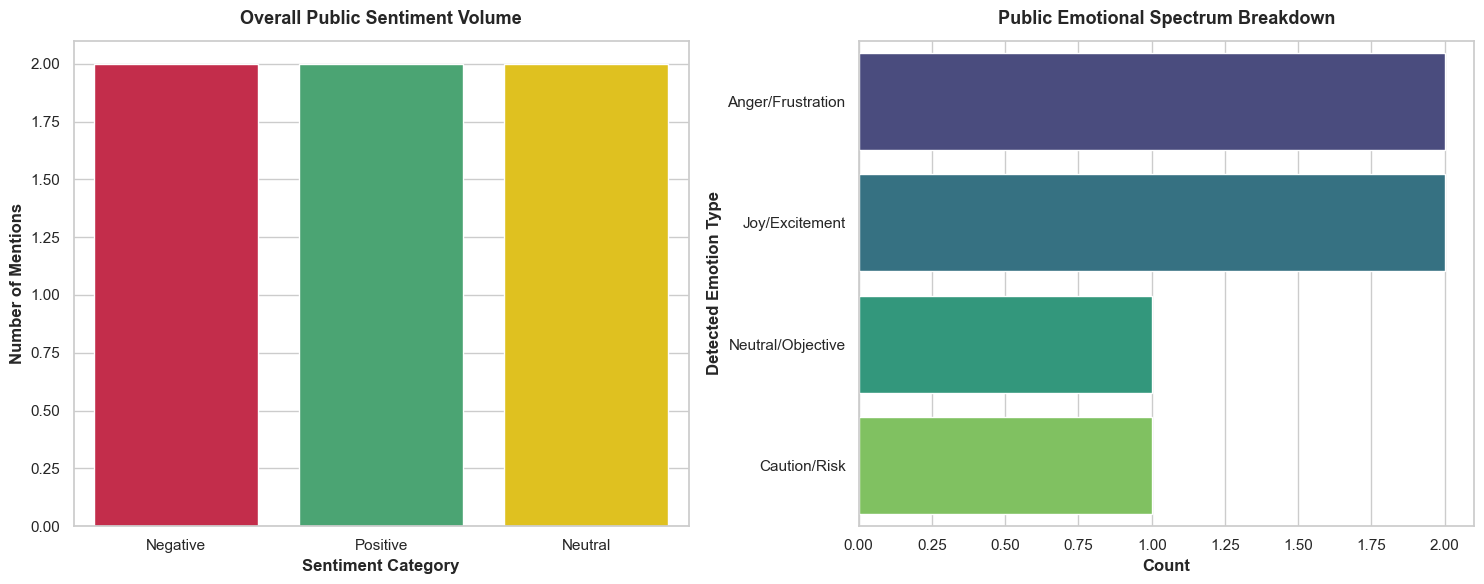

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic style
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Count of Sentiment Categories (Positive vs Negative vs Neutral)
sns.countplot(data=df_nlp, x='Sentiment', hue='Sentiment', palette=['crimson', 'mediumseagreen', 'gold'], ax=ax1, legend=False)
ax1.set_title('Overall Public Sentiment Volume', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Sentiment Category', fontweight='bold')
ax1.set_ylabel('Number of Mentions', fontweight='bold')

# Plot 2: Breakdown of Specific Emotional States
sns.countplot(data=df_nlp, y='Detected_Emotion', hue='Detected_Emotion', palette='viridis', ax=ax2, legend=False)
ax2.set_title('Public Emotional Spectrum Breakdown', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Count', fontweight='bold')
ax2.set_ylabel('Detected Emotion Type', fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
# Save the final NLP dataframe to a local CSV file
df_nlp.to_csv("customer_sentiment_insights.csv", index=False)
print(" Operational Asset Saved! 'customer_sentiment_insights.csv' is ready for deployment.")

 Operational Asset Saved! 'customer_sentiment_insights.csv' is ready for deployment.
